<a href="https://colab.research.google.com/github/agatastachowiak/eeg-motor-imagery-bci/blob/main/notebooks/02_multi_subject_pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install mne
import mne
from mne.datasets import eegbci

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.5/7.5 MB 95.0 MB/s eta 0:00:00
  Attempting uninstall: decorator
    Found existing installation: decorator 4.4.2
    Uninstalling decorator-4.4.2:
      Successfully uninstalled decorator-4.4.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ipython 7.34.0 requires jedi>=0.16, which is not installed.
moviepy 1.0.3 requires decorator<5.0,>=4.0.2, but you have decorator 5.3.1 which is incompatible.


In [3]:
import numpy as np
import mne
from mne.datasets import eegbci

mne.set_log_level('WARNING')  # quiets down the repetitive filter/download messages

subjects = list(range(1, 11))   # start with 10 subjects to keep runtime reasonable
runs = [4, 8, 12]               # imagined left/right fist runs

# This dataset has 14 runs per subject, and they're not all the same task:
#      Runs 1–2: baseline (eyes open/closed, no task)
#      Runs 3, 7, 11: real left/right fist movement (executed, not imagined)
#      Runs 4, 8, 12: imagined left/right fist movement ← this is what we want
#      Runs 5, 9, 13: real both-fists/both-feet movement
#	     Runs 6, 10, 14: imagined both-fists/both-feet movement


all_X = []
all_y = []

for subj in subjects:
    raw_fnames = eegbci.load_data(subj, runs)
    raws = [mne.io.read_raw_edf(f, preload=True) for f in raw_fnames]
    raw = mne.concatenate_raws(raws)  # stitch the 3 runs together into one continuous recording

    raw.filter(l_freq=8, h_freq=30)


    events, event_id = mne.events_from_annotations(raw)

    # filters event_id down to only T1/T2, dropping rest (T0). Now doing a binary classification task: left fist vs. right fist
    picks = {k: v for k, v in event_id.items() if k in ['T1', 'T2']}

    epochs = mne.Epochs(raw, events, event_id=picks, tmin=-0.5, tmax=2.0,
                         baseline=None, preload=True)

    psd_mu = epochs.compute_psd(fmin=8, fmax=12).get_data().mean(axis=2)
    psd_beta = epochs.compute_psd(fmin=13, fmax=30).get_data().mean(axis=2)
    X = np.concatenate([psd_mu, psd_beta], axis=1)
    y = epochs.events[:, -1]

    all_X.append(X)
    all_y.append(y)
    print(f"Subject {subj}: {X.shape[0]} epochs")

X_all = np.concatenate(all_X, axis=0)
y_all = np.concatenate(all_y, axis=0)
print("Final feature matrix shape:", X_all.shape)
print("Final labels shape:", y_all.shape)

Do you want to set the path:
    /root/mne_data
as the default EEGBCI dataset path in the mne-python config [y]/n? y
Subject 1: 45 epochs


Subject 2: 45 epochs


Subject 3: 45 epochs


Subject 4: 45 epochs


Subject 5: 45 epochs


Subject 6: 45 epochs


Subject 7: 45 epochs


Subject 8: 45 epochs


Subject 9: 45 epochs


Subject 10: 45 epochs
Final feature matrix shape: (450, 128)
Final labels shape: (450,)


In [4]:
from sklearn.svm import SVC
from sklearn.model_selection import cross_val_score

clf = SVC(kernel='linear')
scores = cross_val_score(clf, X_all, y_all, cv=5)
print("Cross-validation scores:", scores)
print("Mean accuracy:", scores.mean())

Cross-validation scores: [0.51111111 0.51111111 0.51111111 0.51111111 0.51111111]
Mean accuracy: 0.5111111111111111


In [5]:
import numpy as np
print("Label distribution:", np.bincount(y_all))

Label distribution: [  0   0 230 220]


In [6]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

clf = make_pipeline(StandardScaler(), SVC(kernel='linear'))
scores = cross_val_score(clf, X_all, y_all, cv=5)
print("Cross-validation scores:", scores)
print("Mean accuracy:", scores.mean())

Cross-validation scores: [0.53333333 0.5        0.48888889 0.52222222 0.58888889]
Mean accuracy: 0.5266666666666666


CSP (Common Spatial Patterns) — instead of measuring power at each channel separately, CSP learns combinations of channels (spatial filters) that best tell your two classes apart. It transforms your 64 raw channels into a smaller number of new "virtual channels," each specifically engineered to maximize the difference between left-fist and right-fist imagery. This is the standard feature extraction method in motor imagery BCI research, and it's built into MNE.



In [7]:
import numpy as np
import mne
from mne.datasets import eegbci
from mne.decoding import CSP
from sklearn.svm import SVC
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import cross_val_score

# Keep MNE quiet -- no need the repeated filter/download logs for every subject
mne.set_log_level('WARNING')

# Pre-set the download path so no interaptions
mne.set_config('MNE_DATASETS_EEGBCI_PATH', '/root/mne_data')

subjects = list(range(1, 11))   # subjects 1-10
runs = [4, 8, 12]               # the three "imagined left/right fist" runs

# This time keep the raw epoch arrays (not averaged power), because
# CSP needs to see the full channels x time signal to find spatial patterns
all_epochs_data = []
all_labels = []

for subj in subjects:
    # Download and load this subject's 3 runs
    raw_fnames = eegbci.load_data(subj, runs)
    raws = [mne.io.read_raw_edf(f, preload=True) for f in raw_fnames]
    raw = mne.concatenate_raws(raws)  # stitch the 3 runs into one continuous recording

    # Band-pass filter to the mu/beta range, same as before
    raw.filter(l_freq=8, h_freq=30)

    # Get event timings and keep only T1 (left fist) / T2 (right fist)
    events, event_id = mne.events_from_annotations(raw)
    picks = {k: v for k, v in event_id.items() if k in ['T1', 'T2']}

    # Cut into labeled trials
    epochs = mne.Epochs(raw, events, event_id=picks, tmin=-0.5, tmax=2.0,
                         baseline=None, preload=True)

    # .get_data() here gives us shape (n_epochs, n_channels, n_timepoints)
    # -- this is the "raw" epoch data CSP needs, unlike earlier averaged features
    epochs_data = epochs.get_data()
    labels = epochs.events[:, -1]

    all_epochs_data.append(epochs_data)
    all_labels.append(labels)
    print(f"Subject {subj}: {epochs_data.shape[0]} epochs")

# Stack every subject's epochs together into one big array
# axis=0 means stacking along the "epochs" dimension, keeping channels/timepoints unchanged
X_all_epochs = np.concatenate(all_epochs_data, axis=0)
y_all = np.concatenate(all_labels, axis=0)

print("Combined epoch data shape:", X_all_epochs.shape)  # (total_epochs, channels, timepoints)
print("Combined labels shape:", y_all.shape)

Subject 1: 45 epochs
Subject 2: 45 epochs
Subject 3: 45 epochs
Subject 4: 45 epochs
Subject 5: 45 epochs
Subject 6: 45 epochs
Subject 7: 45 epochs
Subject 8: 45 epochs
Subject 9: 45 epochs
Subject 10: 45 epochs
Combined epoch data shape: (450, 64, 401)
Combined labels shape: (450,)


What is happening: CSP will look at the full channel × time signal for each epoch, learn which channel combinations best separate left-fist from right-fist trials, and output a small number of highly informative features per epoch. Then SVM classifies based on those.

In [8]:
from mne.decoding import CSP
from sklearn.svm import SVC
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import cross_val_score

# n_components: how many spatial filters CSP should learn.
# 4 is a common starting point in the literature -- enough to capture
# the main discriminative patterns without overfitting on ~450 samples
csp = CSP(n_components=4, reg=None, log=True, norm_trace=False)

# Chain CSP (feature extraction) and SVM (classification) into one pipeline,
# so CSP is learned freshly within each cross-validation fold -- this avoids
# "peeking" at test data when CSP is fit, which would inflate the accuracy dishonestly
clf = make_pipeline(csp, SVC(kernel='linear'))

scores = cross_val_score(clf, X_all_epochs, y_all, cv=5)
print("Cross-validation scores:", scores)
print("Mean accuracy:", scores.mean())

Cross-validation scores: [0.58888889 0.54444444 0.46666667 0.54444444 0.52222222]
Mean accuracy: 0.5333333333333333


In [9]:
# Isolate just subject 1's epochs (the first 45, since each subject gave exactly 45)
X_subj1 = X_all_epochs[:45]
y_subj1 = y_all[:45]

csp = CSP(n_components=4, reg=None, log=True, norm_trace=False)
clf = make_pipeline(csp, SVC(kernel='linear'))

scores = cross_val_score(clf, X_subj1, y_subj1, cv=5)
print("Subject 1 - Cross-validation scores:", scores)
print("Subject 1 - Mean accuracy:", scores.mean())

Subject 1 - Cross-validation scores: [0.77777778 0.88888889 0.66666667 0.88888889 0.66666667]
Subject 1 - Mean accuracy: 0.7777777777777777


What just happened

Subject 1 alone: ~78% accuracy (with individual folds up to 89%) vs. pooled across 10 subjects: ~53%. That's a massive, meaningful difference: the signal is real and strongly decodable — but it's subject-specific.

Finding in BCI research: within-subject decoding works well; cross-subject/pooled decoding is a much harder, actively-researched problem.

In [10]:
subject_accuracies = []

for i in range(10):
    start = i * 45
    end = start + 45
    X_subj = X_all_epochs[start:end]
    y_subj = y_all[start:end]

    csp = CSP(n_components=4, reg=None, log=True, norm_trace=False)
    clf = make_pipeline(csp, SVC(kernel='linear'))

    scores = cross_val_score(clf, X_subj, y_subj, cv=5)
    subject_accuracies.append(scores.mean())
    print(f"Subject {i+1}: {scores.mean():.3f}")

print("\nAverage within-subject accuracy:", np.mean(subject_accuracies))
print("Std across subjects:", np.std(subject_accuracies))

Subject 1: 0.778
Subject 2: 0.511
Subject 3: 0.578
Subject 4: 0.533
Subject 5: 0.489
Subject 6: 0.467
Subject 7: 0.867
Subject 8: 0.511
Subject 9: 0.578
Subject 10: 0.578

Average within-subject accuracy: 0.5888888888888888
Std across subjects: 0.12382783747337806


What you're seeing: Two subjects performed clearly above chance (Subject 1: 77.8%, Subject 7: 86.7%), while most others hovered close to chance level (50%) — some even slightly below, which for such small sample sizes is just noise.

This pattern in BCI literature is called "BCI illiteracy" — a meaningful subset of people (often cited as 15-30% in the literature) don't produce strong, decodable motor imagery signals, for reasons that are still actively researched (attention, task engagement, individual neuroanatomy, whether they're truly imagining movement vividly vs. just thinking about the word "left"). Your data — 2 out of 10 subjects clearly decodable, rest near chance — lines up with this exactly.

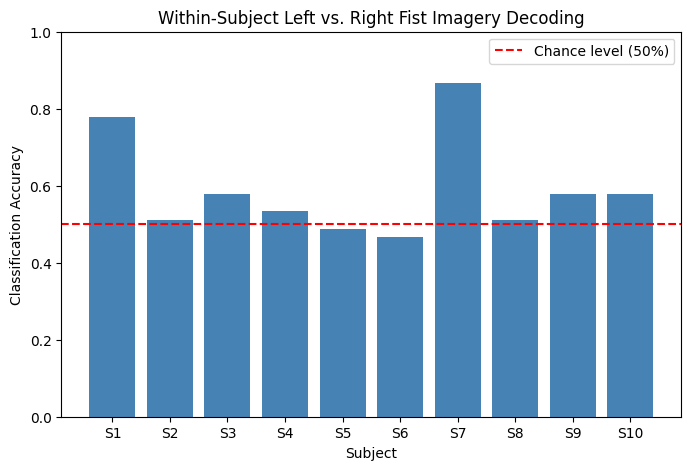

In [11]:
import matplotlib.pyplot as plt

subjects_labels = [f"S{i+1}" for i in range(10)]

plt.figure(figsize=(8, 5))
plt.bar(subjects_labels, subject_accuracies, color='steelblue')
plt.axhline(y=0.5, color='red', linestyle='--', label='Chance level (50%)')
plt.ylabel('Classification Accuracy')
plt.xlabel('Subject')
plt.title('Within-Subject Left vs. Right Fist Imagery Decoding')
plt.legend()
plt.ylim(0, 1)
plt.savefig('subject_accuracy.png', dpi=150, bbox_inches='tight')
plt.show()